#Alina Shrestha
#2408564
#Worksheet03



#Question- 1: List out all the limitations of MCP- Neurons.


ans) The limitations of MCP- Neurons are:
1) No Learning Ability
MCP neurons do not learn from data. The weights and threshold must be manually defined.

2)  Inputs Only
It only works with binary inputs (0 or 1), making it unrealistic for real-world problems.

3) No Weights (Equal Importance)
All inputs are treated equally. There is no concept of different importance (weights).

4) Cannot Handle Complex Problems
MCP neurons can only solve simple logical functions like AND and OR.

5) Cannot Solve Non-Linearly Separable Problems
It fails to solve problems like XOR.

6) Oversimplified Biological Model
It is too simple to represent real neurons accurately.

#Question- 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.{Can you devise a if else rules.}



ans) A single MCP neuron cannot solve the XOR problem because it cannot separate the inputs using just one threshold. However, we can still achieve XOR by combining multiple MCP neurons using simple logic rules. XOR can be understood as: the output is 1 when either X1 or X2 is 1, but not when both are 1. In simple terms, we can first check if at least one input is 1 (OR condition), then check if both inputs are 1 (AND condition), and finally ignore the case where both are 1. This can be written as: XOR = (X1 OR X2) AND NOT (X1 AND X2). So, while one MCP neuron is not enough, we can use multiple neurons together with if-else logic to correctly compute the XOR function.




### Question 3: What does the weights array represent in this context?




ans) The weights array represents the importance of each input feature (pixel) in making a prediction. Since each image has many pixels, each weight corresponds to one pixel and determines how much that pixel contributes to the final decision. During training, these weights are adjusted so that the model can correctly classify the images.




### Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?

.

ans) We initialize the weights to zero because the model starts without any prior knowledge and learns from scratch. Starting with zero ensures a simple and neutral beginning. During training, the weights are gradually updated based on errors, allowing the model to learn patterns in the data. In the case of a perceptron, initializing to zero does not cause major issues, as the weights will change during learning and still lead to a correct solution if the data is linearly separable.

#1.Question-5:Whatisthepurposeoftheoutput=np.dot(X[i],weights)+biasline?








ans) The line `output = np.dot(X[i], weights) + bias` calculates the weighted sum of the input features plus the bias, which is the net input used by the perceptron to decide whether to output 0 or 1.


# Question- 6: What happens when the prediction is wrong? How are the weights and bias updated?

ans) When the prediction is wrong, the perceptron updates the weights and bias using the formula `weights += learning_rate * (y[i] - y_pred) * X[i]` and `bias += learning_rate * (y[i] - y_pred)` to adjust the decision boundary for correct classification in the future.


#3. Question- 7:Why is the final accuracy important, and what do you expect it to be?

ans) The final accuracy shows how well the perceptron has learned to classify the dataset. For the 0 vs 1 MNIST dataset, it is expected to be close to 100% because these two classes are linearly separable.



#Question- 8:What does misclassified idx store, and how is it used in this code?



ans) "Misclassified_idx" is a list that keeps track of all the data points where the perceptron made a mistake. Think of it like a teacher marking which answers on a test were wrong. Each number in this list shows the position of a picture that the perceptron predicted incorrectly. In the code, we use this list to find those specific pictures and display them, so we can see exactly where the model struggled. This helps us understand the mistakes and learn which images were tricky for the perceptron.


#2. Question- 9: How do you interpret the result if the output is ”All images were correctly classified!”?


ans) If the output says “All images were correctly classified!”, it means the perceptron got every single picture right. Imagine finishing a test and getting a perfect score—no mistakes at all. In this case, the perceptron was able to learn perfectly from the training data, and its rules for deciding whether a picture is 0 or 1 worked for every example. This shows that the model is doing its job exactly as expected.



#4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.



#Step 1: Load the dataset

In [3]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

# Load dataset
import pandas as pd

# Use the exact file name after uploading
df_3_5 = pd.read_csv("mnist_3_and_5.csv")
# Extract features and labels
X = df_3_5.drop(columns=["label"]).values  # pixel values
y = df_3_5["label"].values                 # labels 3 or 5

# Optional: Convert labels to binary: 3 -> 0, 5 -> 1
y_binary = np.where(y == 3, 0, 1)

print("Features shape:", X.shape)
print("Labels shape:", y_binary.shape)

Saving mnist_3_and_5.csv to mnist_3_and_5.csv
Features shape: (2741, 784)
Labels shape: (2741,)


#Step 2: Initialize weights and bias

In [4]:
# Number of features (pixels)
n_features = X.shape[1]

# Initialize weights and bias
weights = np.zeros(n_features)
bias = 0

# Learning parameters
learning_rate = 0.1
epochs = 100

#Step 3: Define the Perceptron training function

In [5]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    n_samples = X.shape[0]

    for epoch in range(epochs):
        correct = 0
        for i in range(n_samples):
            # Weighted sum
            output = np.dot(X[i], weights) + bias
            # Step function
            y_pred = 1 if output >= 0 else 0

            # Update weights if prediction is wrong
            if y_pred != y[i]:
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate * (y[i] - y_pred)
            else:
                correct += 1
        # Optional: print accuracy per epoch
        # print(f"Epoch {epoch+1}: {(correct/n_samples)*100:.2f}%")

    accuracy = correct / n_samples
    return weights, bias, accuracy

#Step 4: Train the perceptron

In [6]:
weights, bias, final_accuracy = train_perceptron(X, y_binary, weights, bias, learning_rate, epochs)
print("Final training accuracy:", final_accuracy)

Final training accuracy: 0.9857716161984678


#Step 5: Make predictions

In [7]:
# Compute predictions
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

#Step 6: Identify misclassified images


In [8]:
misclassified_idx = np.where(y_pred != y_binary)[0]
print("Number of misclassified images:", len(misclassified_idx))

Number of misclassified images: 36


#Step 7: Visualize misclassified images

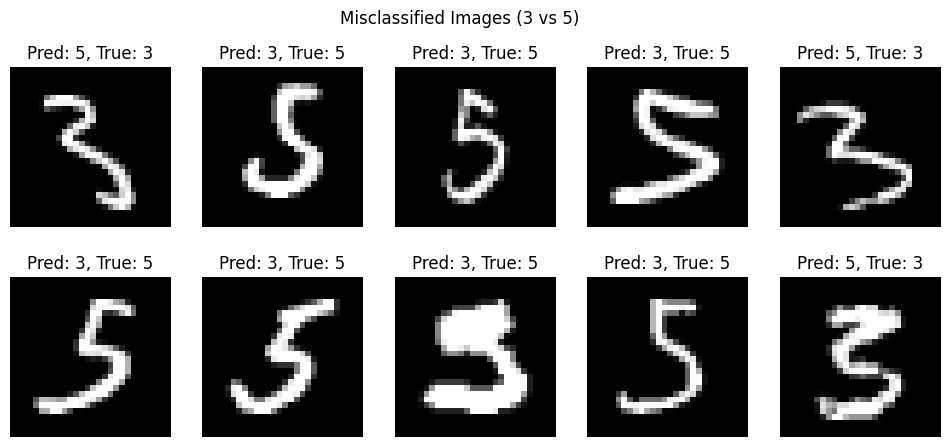

In [9]:
import matplotlib.pyplot as plt

# Show up to 10 misclassified images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.flat, misclassified_idx[:10]):
    ax.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {y_pred[idx]*2 + 3}, True: {y_binary[idx]*2 + 3}")  # Convert back to 3 or 5
    ax.axis('off')

plt.suptitle("Misclassified Images (3 vs 5)")
plt.show()

#Explaination

The perceptron was able to classify most 3s and 5s correctly, but some images were misclassified because the digits 3 and 5 look very similar in certain handwritten samples. This shows that a simple perceptron may not perfectly separate digits that are not linearly separable.